<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [3]:
# your solution
cars.info()
cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


Speed is explanatory and distance is response because, in an experiment, we can control the speed of the car and measure the corresponding braking distance (but the inverse would be impossible).

## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

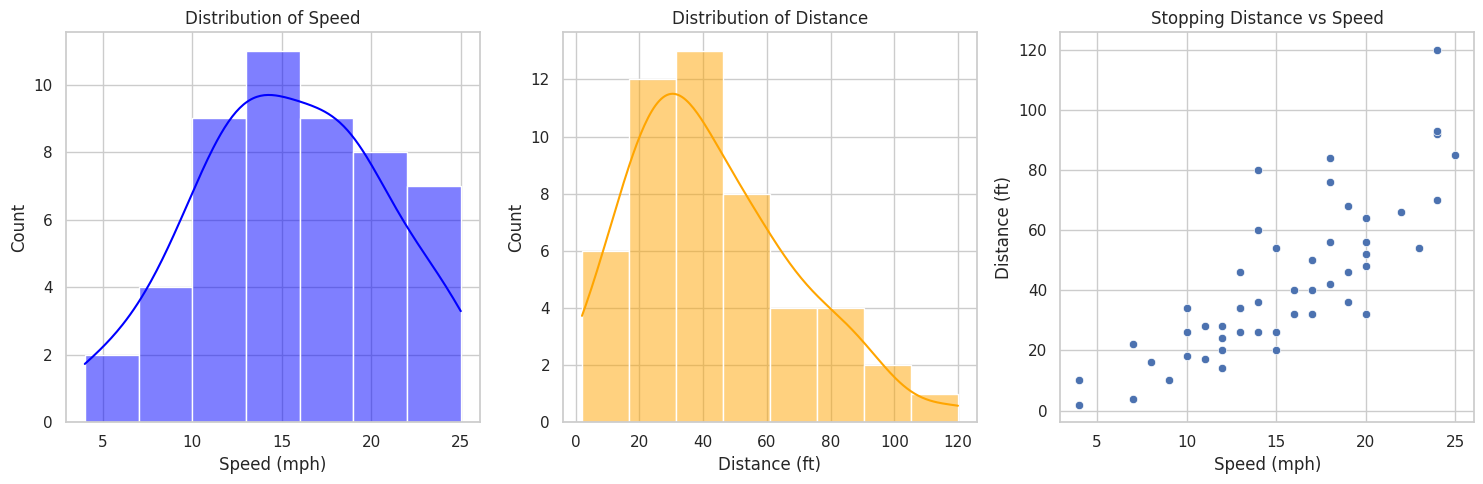

In [4]:
# your solution
# Create subplots for histograms and scatter plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram with density curve for speed
sns.histplot(cars['speed'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Speed')
axes[0].set_xlabel('Speed (mph)')

# Histogram with density curve for dist
sns.histplot(cars['dist'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Distance')
axes[1].set_xlabel('Distance (ft)')

# Scatter plot of dist against speed
sns.scatterplot(x='speed', y='dist', data=cars, ax=axes[2])
axes[2].set_title('Stopping Distance vs Speed')
axes[2].set_xlabel('Speed (mph)')
axes[2].set_ylabel('Distance (ft)')

plt.tight_layout()
plt.show()

Negative speed and braking distance are impossible so the kernel density estimates in the first two plots do not make sense if extended towards the negative region. Otherwise the speed histogram seems relatively centered around cca 15mph (or slightly skewed to the right) while the distance plot is skewed to the left. The scatter plot suggests there is correlation between speed and stoping distance and the variance in distance seems to grow with speed and the curve seems more quadratic or exponential than linear to me.

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

In [5]:
# your solution
x = cars['speed'].values
y = cars['dist'].values
n = len(cars)

# Model with intercept
x_mean = np.mean(x)
y_mean = np.mean(y)

Sxx = np.sum((x - x_mean)**2)
Sxy = np.sum((x - x_mean) * (y - y_mean))

beta1_hat = Sxy / Sxx
beta0_hat = y_mean - beta1_hat * x_mean

# Model without intercept (through the origin)
beta1_no_int_hat = np.sum(x * y) / np.sum(x**2)

print(f"Model with intercept: beta0_hat = {beta0_hat:.4f}, beta1_hat = {beta1_hat:.4f}")
print(f"Model without intercept: beta1_hat = {beta1_no_int_hat:.4f}")

Model with intercept: beta0_hat = -17.5791, beta1_hat = 3.9324
Model without intercept: beta1_hat = 2.9091


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [6]:
# your solution
# Fitted values and residuals for model with intercept
y_hat_int = beta0_hat + beta1_hat * x
res_int = y - y_hat_int
SSE_int = np.sum(res_int**2)
sn2_int = SSE_int / (n - 2)

# Fitted values and residuals for model without intercept
y_hat_no_int = beta1_no_int_hat * x
res_no_int = y - y_hat_no_int
SSE_no_int = np.sum(res_no_int**2)
sn2_no_int = SSE_no_int / (n - 1)

print(f"Model with intercept: SSE = {SSE_int:.4f}, sn2 = {sn2_int:.4f}")
print(f"Model without intercept: SSE = {SSE_no_int:.4f}, sn2 = {sn2_no_int:.4f}")

Model with intercept: SSE = 11353.5211, sn2 = 236.5317
Model without intercept: SSE = 12953.7768, sn2 = 264.3628


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

**WITH intercept:**

we minimise: $$S(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2$$
 which yields (was done at the lecture via Lagrange multiplikators)
$$\hat{\beta}_1 = \frac{n \sum_i x_i y_i - \sum_i x_i \sum_i y_i}{n \sum_i x_i^2 - (\sum_i x_i)^2}, \quad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$



**WITHOUT intercept:**

we minimize
$$S(\beta_1) = \sum_i (y_i - \beta_1 x_i)^2$$

with the constraint
$$\frac{\partial S}{\partial \beta_1} = -2 \sum_i x_i(y_i - \beta_1 x_i) = 0 $$
which yields
$$\sum_i x_i y_i = \beta_1 \sum_i x_i^2,$$

and finally

$$\hat{\beta}_1 = \frac{\sum_i x_i y_i}{\sum_i x_i^2}.$$

In [7]:
# your solution
# Manual standard error calculations
se_beta1_int = np.sqrt(sn2_int / Sxx)
se_beta0_int = np.sqrt(sn2_int * (1/n + (x_mean**2)/Sxx))
se_beta1_no_int = np.sqrt(sn2_no_int / np.sum(x**2))

print("--- Manual Standard Errors ---")
print(f"With intercept: SE(beta0) = {se_beta0_int:.4f}, SE(beta1) = {se_beta1_int:.4f}")
print(f"Without intercept: SE(beta1) = {se_beta1_no_int:.4f}")

# Statsmodels verification
print("\n--- Statsmodels Verification ---")
X_int = sm.add_constant(x)
sm_model_int = sm.OLS(y, X_int).fit()
print(f"With intercept SEs: {sm_model_int.bse}")

sm_model_no_int = sm.OLS(y, x).fit()
print(f"Without intercept SEs: {sm_model_no_int.bse}")

--- Manual Standard Errors ---
With intercept: SE(beta0) = 6.7584, SE(beta1) = 0.4155
Without intercept: SE(beta1) = 0.1414

--- Statsmodels Verification ---
With intercept SEs: [6.75844017 0.41551278]
Without intercept SEs: [0.14136864]


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

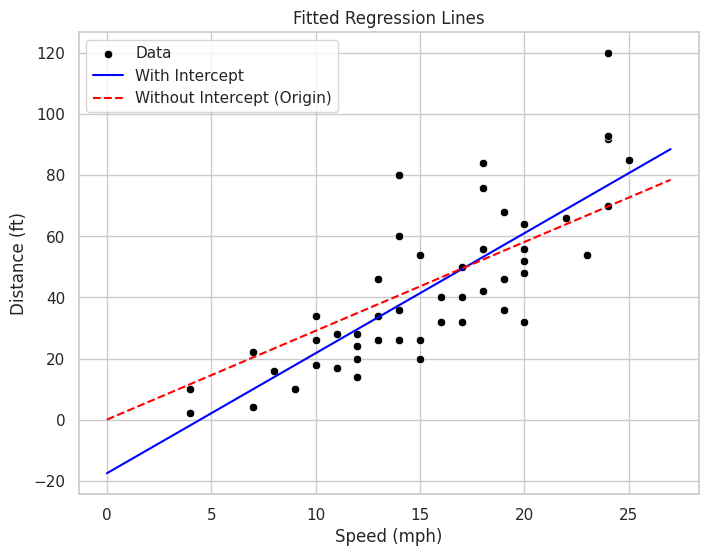

In [8]:
# your solution
plt.figure(figsize=(8, 6))
sns.scatterplot(x='speed', y='dist', data=cars, color='black', label='Data')

# Plot lines
x_vals = np.linspace(0, max(x) + 2, 100)
plt.plot(x_vals, beta0_hat + beta1_hat * x_vals, color='blue', label='With Intercept')
plt.plot(x_vals, beta1_no_int_hat * x_vals, color='red', linestyle='--', label='Without Intercept (Origin)')

plt.xlabel('Speed (mph)')
plt.ylabel('Distance (ft)')
plt.title('Fitted Regression Lines')
plt.legend()
plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

In [9]:
# your solution
print(f"Slope with intercept: {beta1_hat:.4f}")
print(f"Slope without intercept: {beta1_no_int_hat:.4f}")


Slope with intercept: 3.9324
Slope without intercept: 2.9091


Negative braking distance does not make sense, so from that perspective the one without intercept makes more sense. The slope is steeper without the interceot because no intercept enforces that the line must pass through the origin while the one with intercept can start in the negatives (although it does not make sense physics-wise)

## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [10]:
# your solution
speeds_to_predict = np.array([20, 30])

pred_int = beta0_hat + beta1_hat * speeds_to_predict
pred_no_int = beta1_no_int_hat * speeds_to_predict

print(f"Predictions at 20 mph:")
print(f"  With intercept: {pred_int[0]:.2f} ft")
print(f"  Without intercept: {pred_no_int[0]:.2f} ft")

print(f"\nPredictions at 30 mph:")
print(f"  With intercept: {pred_int[1]:.2f} ft")
print(f"  Without intercept: {pred_no_int[1]:.2f} ft")

Predictions at 20 mph:
  With intercept: 61.07 ft
  Without intercept: 58.18 ft

Predictions at 30 mph:
  With intercept: 100.39 ft
  Without intercept: 87.27 ft


The 30mph one is the extrapolation. I would suppose that the model without intercept is too optimistic to be plausible (the one with the intercept is also optimistic).

## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

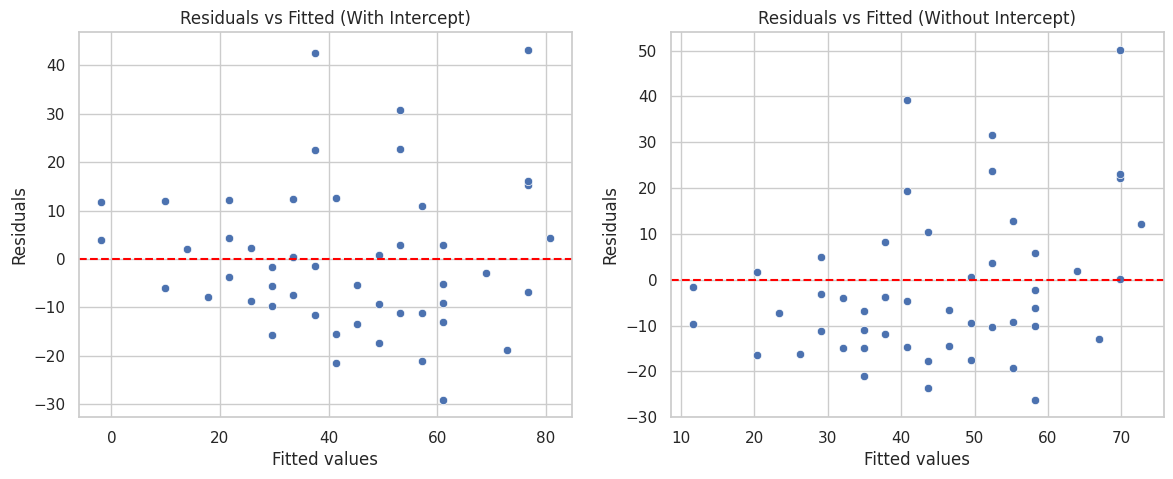

In [11]:
# your solution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for model with intercept
sns.scatterplot(x=y_hat_int, y=res_int, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (With Intercept)')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# Residuals for model without intercept
sns.scatterplot(x=y_hat_no_int, y=res_no_int, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted (Without Intercept)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

plt.show()

The one with intercept becuase the values seem more evenly distributed around 0, which would be expectedd of random noise. But both patterns suggest that the variance in stopping distance increases with speed.

## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [12]:
# your solution
# Add an artificial outlier: very high distance at very low speed
cars_outlier = pd.concat([cars, pd.DataFrame({'speed': [4], 'dist': [120]})], ignore_index=True)

x_out = cars_outlier['speed'].values
y_out = cars_outlier['dist'].values

# Refit model with intercept
X_out_int = sm.add_constant(x_out)
mod_out_int = sm.OLS(y_out, X_out_int).fit()

# Refit model without intercept
mod_out_no_int = sm.OLS(y_out, x_out).fit()

print("--- Original Coefficients ---")
print(f"With intercept: b0 = {beta0_hat:.4f}, b1 = {beta1_hat:.4f}")
print(f"Without intercept: b1 = {beta1_no_int_hat:.4f}")

print("\n--- Coefficients with Outlier ---")
print(f"With intercept: b0 = {mod_out_int.params[0]:.4f}, b1 = {mod_out_int.params[1]:.4f}")
print(f"Without intercept: b1 = {mod_out_no_int.params[0]:.4f}")

--- Original Coefficients ---
With intercept: b0 = -17.5791, b1 = 3.9324
Without intercept: b1 = 2.9091

--- Coefficients with Outlier ---
With intercept: b0 = -1.3874, b1 = 3.0229
Without intercept: b1 = 2.9419


The one with intercept is more sensitive.

## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

                                 OLS Regression Results                                
Dep. Variable:                   dist   R-squared (uncentered):                   0.904
Model:                            OLS   Adj. R-squared (uncentered):              0.902
Method:                 Least Squares   F-statistic:                              463.8
Date:                Mon, 05 Oct 2026   Prob (F-statistic):                    1.24e-26
Time:                        07:32:06   Log-Likelihood:                         -207.83
No. Observations:                  50   AIC:                                      417.7
Df Residuals:                      49   BIC:                                      419.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

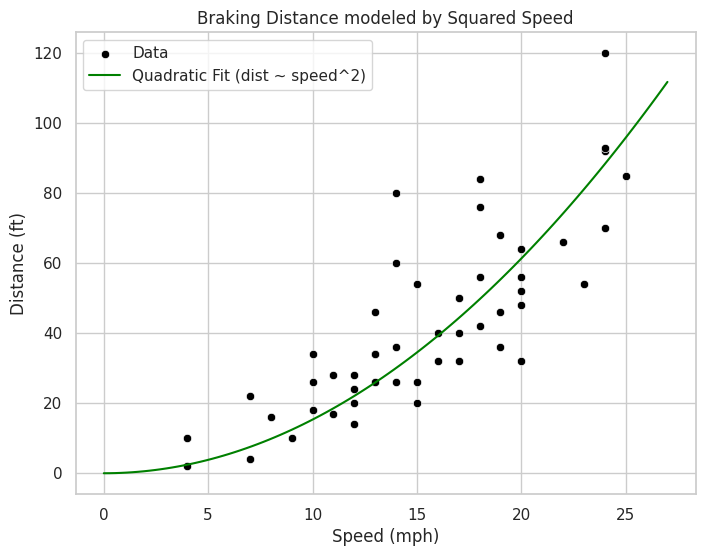

In [13]:
# your solution
# Experiment: Predict distance using squared speed
cars['speed_sq'] = cars['speed']**2

# Fit quadratic model (without intercept, as 0 speed = 0 kinetic energy)
mod_sq = smf.ols('dist ~ speed_sq - 1', data=cars).fit()
print(mod_sq.summary())

# Plot the new fit
plt.figure(figsize=(8, 6))
sns.scatterplot(x='speed', y='dist', data=cars, color='black', label='Data')

x_vals = np.linspace(0, max(cars['speed']) + 2, 100)
y_pred_sq = mod_sq.params.iloc[0] * (x_vals**2)

plt.plot(x_vals, y_pred_sq, color='green', label='Quadratic Fit (dist ~ speed^2)')
plt.xlabel('Speed (mph)')
plt.ylabel('Distance (ft)')
plt.title('Braking Distance modeled by Squared Speed')
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     95.67
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           5.20e-13
Time:                        07:32:07   Log-Likelihood:                -205.49
No. Observations:                  50   AIC:                             415.0
Df Residuals:                      48   BIC:                             418.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.8600      4.086      2.168      0.0

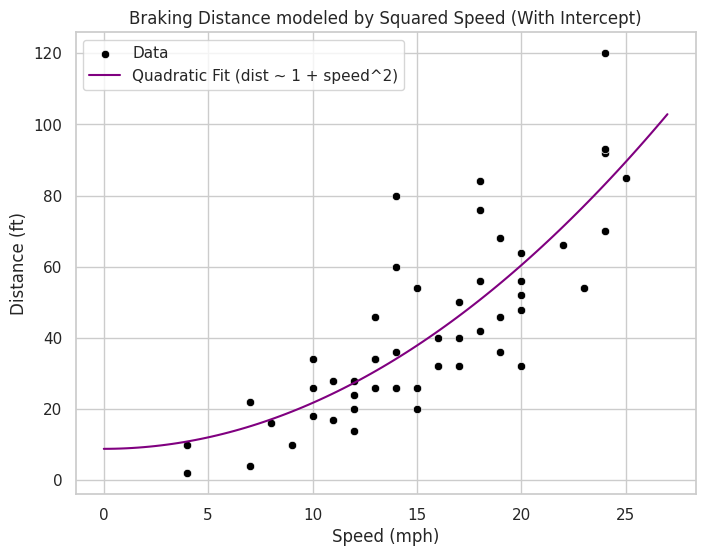

In [14]:
# Experiment: Predict distance using squared speed (with intercept)
cars['speed_sq'] = cars['speed']**2

# Fit quadratic model with intercept
mod_sq_int = smf.ols('dist ~ speed_sq', data=cars).fit()
print(mod_sq_int.summary())

# Plot the new fit
plt.figure(figsize=(8, 6))
sns.scatterplot(x='speed', y='dist', data=cars, color='black', label='Data')

x_vals = np.linspace(0, max(cars['speed']) + 2, 100)
b0_sq = mod_sq_int.params['Intercept']
b1_sq = mod_sq_int.params['speed_sq']
y_pred_sq_int = b0_sq + b1_sq * (x_vals**2)

plt.plot(x_vals, y_pred_sq_int, color='purple', label='Quadratic Fit (dist ~ 1 + speed^2)')
plt.xlabel('Speed (mph)')
plt.ylabel('Distance (ft)')
plt.title('Braking Distance modeled by Squared Speed (With Intercept)')
plt.legend()
plt.show()

Solutions: either square the speed variable or predict the square root of the distance. Above is the former.

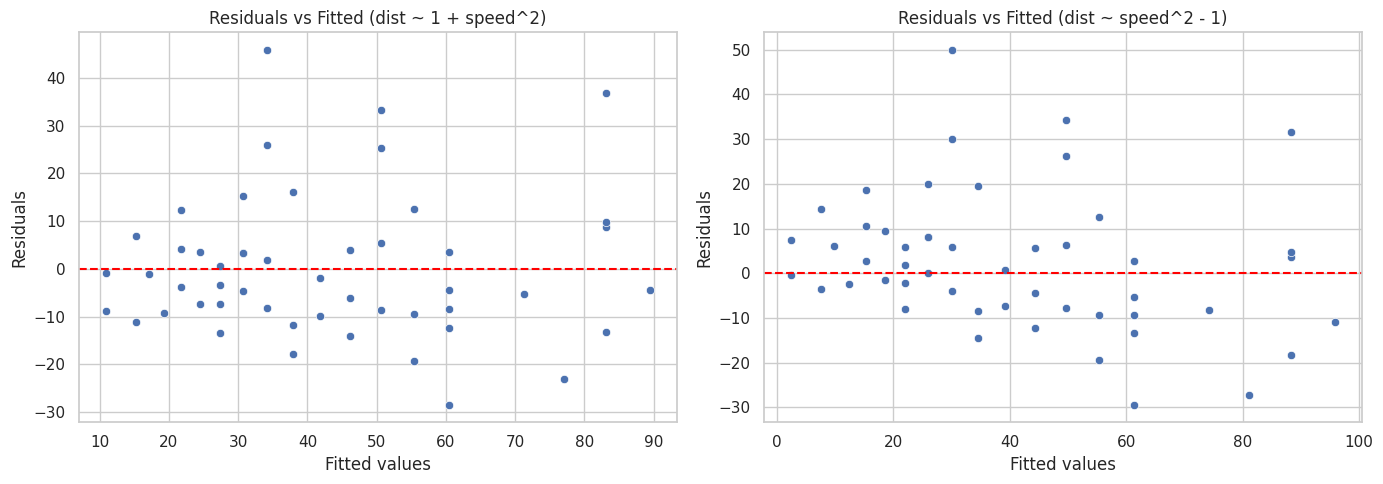

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals for quadratic model WITH intercept
sns.scatterplot(x=mod_sq_int.fittedvalues, y=mod_sq_int.resid, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted (dist ~ 1 + speed^2)')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

# Residuals for quadratic model WITHOUT intercept
sns.scatterplot(x=mod_sq.fittedvalues, y=mod_sq.resid, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Fitted (dist ~ speed^2 - 1)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()